# Polynomial Feature for Linear Regression

## 1. Determining Nonlinearity

Before increasing model complexity with polynomial features, we must find empirical evidence that the relationship between the predictor ($X$) and the target variable ($Y$) is not a straight line. 

### 1.1 Load and Prepare Data
First, we load the cleaned training data (in `Data_Preparation`) saved from our preprocessing pipeline. We then concatenate the features (`X_train`) and the target (`y_train`) into a single DataFrame. This allows us to use the `statsmodels` formula syntax for easier model fitting.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Load the preprocessed training datasets
train_data = pd.read_csv('../data/train_data/train.csv')
test_data = pd.read_csv('../data/test_data/test.csv')


print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")
print("\nData columns:", train_data.columns.tolist())
print("\nData types:")
print(train_data.dtypes)
# display(train_data[['Item_MRP', 'Item_Outlet_Sales']].head())
train_data.head()

Training data shape: (6818, 10)
Test data shape: (1705, 10)

Data columns: ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Years', 'Item_Outlet_Sales']

Data types:
Item_Weight             float64
Item_Fat_Content         object
Item_Visibility         float64
Item_Type                object
Item_MRP                float64
Outlet_Size              object
Outlet_Location_Type     object
Outlet_Type              object
Outlet_Years              int64
Item_Outlet_Sales       float64
dtype: object


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Years,Item_Outlet_Sales
0,9.500,Regular,0.035206,Fruits and Vegetables,171.3448,Medium,Tier 1,Supermarket Type1,14,2386.2272
1,18.000,Non-Edible,0.047473,Household,170.5422,Small,Tier 2,Supermarket Type1,11,3103.9596
2,17.600,Regular,0.076122,Meat,111.7202,Small,Tier 1,Supermarket Type1,16,1125.2020
3,8.325,Low Fat,0.029845,Fruits and Vegetables,41.6138,Small,Tier 2,Supermarket Type1,11,284.2966
4,12.850,Low Fat,0.137228,Snack Foods,155.5630,Small,Tier 1,Supermarket Type1,16,4224.5010


### 1.2 Feature Selection and Multi-Variable Visualization

Instead of focusing solely on one variable, we will now identify all continuous numerical features from the dataset. This comprehensive approach allows us to:
1. **Identify Candidates:** Detect which variables show the strongest non-linear patterns (curves, clusters) relative to `Item_Outlet_Sales`.
2. **Justify Complexity:** Provide a broader empirical basis for why we choose specific features for polynomial transformation later.

We will exclude categorical variables (even if encoded) because polynomial terms ($X^2, X^3$) are mathematically designed for continuous data.

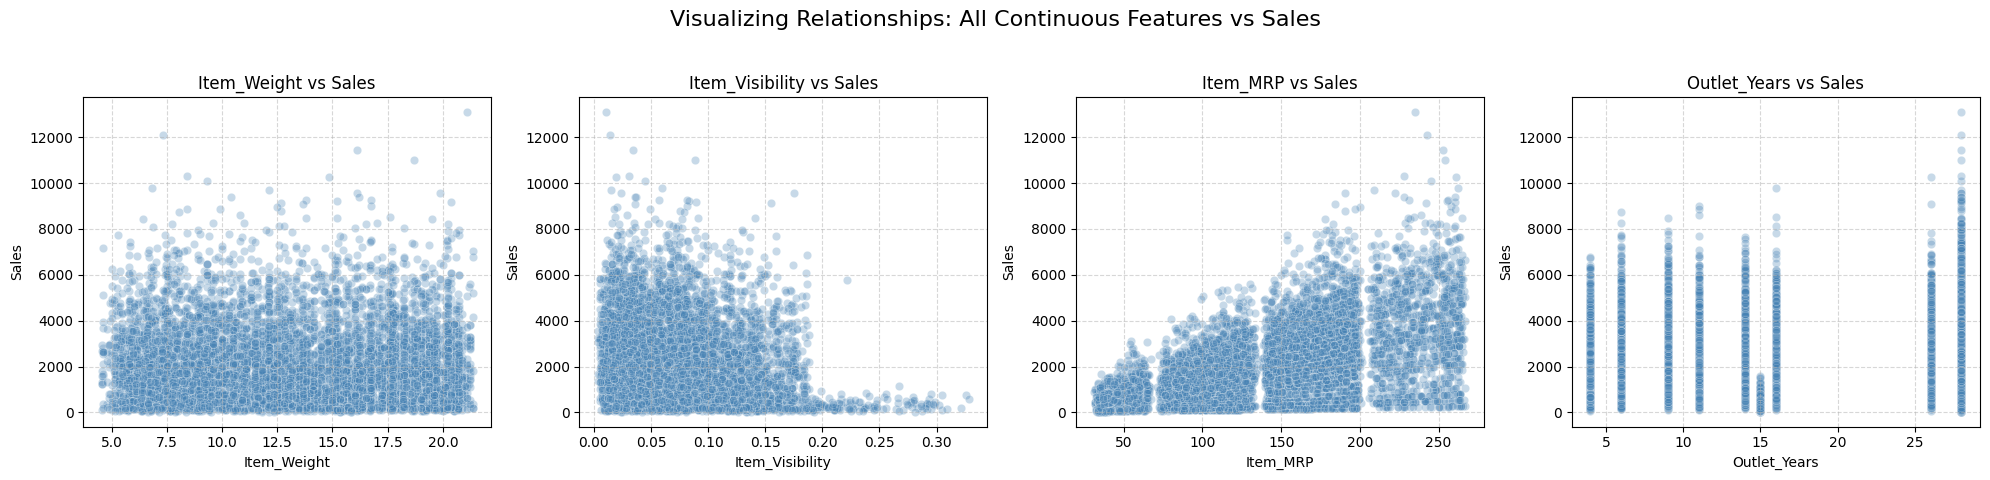

In [99]:
# Exclude 'Item_Outlet_Sales' (target) and typically binary/encoded columns
continuous_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']  

num_features = len(continuous_features)
fig, axes = plt.subplots(nrows=1, ncols=num_features, figsize=(20, 5))
fig.suptitle('Visualizing Relationships: All Continuous Features vs Sales', fontsize=16)

for i, col in enumerate(continuous_features):
    sns.scatterplot(
        x=col, 
        y='Item_Outlet_Sales', 
        data=train_data, 
        ax=axes[i], 
        alpha=0.3, 
        color='steelblue', 
        edgecolor='w'
    )
    axes[i].set_title(f'{col} vs Sales')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Sales')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Observations from Multi-Variable Scatter Plots**

A preliminary visual inspection of the continuous features against `Item_Outlet_Sales` reveals several critical patterns:

* **Item_MRP (Primary Predictor):** There is a clear positive correlation between price and sales. However, the data is not a uniform "cloud"; it appears in distinct vertical clusters, suggesting that price segments might react differently to a linear fit.
* **Item_Visibility:** The data is heavily concentrated at lower visibility levels (mostly below 0.2), indicating a strongly right-skewed distribution. There is no clear linear relationship between visibility and sales, as the points are widely scattered without a distinct trend. Higher visibility values are sparse and tend to be associated with lower or moderate sales, suggesting that this feature may have limited predictive power in its current form.
* **Item_Weight & Outlet_Age:** These features show a much more dispersed and "flat" relationship with sales, indicating they may play a secondary role compared to price.

### 1.3 Baseline Linear Model Fitting

To statistically confirm the necessity of polynomial terms, we first fit a **Simple Linear Regression** model ($Y = \beta_0 + \beta_1 X$). 

We will use `Item_MRP` as the primary predictor for this baseline because it showed the strongest potential for a structured relationship in the previous scatter plots. The goal is to capture the "linear" portion of the data so we can analyze what remains unexplained (the residuals).

In [100]:
# Fit an Ordinary Least Squares (OLS) model: Sales predicted by MRP
baseline_model = smf.ols(formula='Item_Outlet_Sales ~ Item_MRP', data=train_data).fit()

print("--- Baseline Linear Model Summary ---")
print(baseline_model.summary())

--- Baseline Linear Model Summary ---
                            OLS Regression Results                            
Dep. Variable:      Item_Outlet_Sales   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     3201.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:13:21   Log-Likelihood:                -59156.
No. Observations:                6818   AIC:                         1.183e+05
Df Residuals:                    6816   BIC:                         1.183e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     

**Statistical Analysis of OLS Results:**

* **Model Explanatory Power ($R^{2}$):** The model achieved an $R^{2}$ of **0.320**, meaning `Item_MRP` explains approximately **32%** of the variance in sales. While this shows a significant relationship, 68% of the variance remains unexplained by a simple linear fit.
* **Significance of Predictor:** The $p$-value for `Item_MRP` is **0.000**, which is much lower than the alpha level of 0.05. This confirms that price is a statistically significant driver of sales.
* **Coefficient Interpretation:** The coefficient of **15.5455** indicates that for every 1-unit increase in `Item_MRP`, sales are expected to increase by approximately 15.55 units.
* **Intercept:** The intercept (-3.6158) has a $p$-value of 0.932, suggesting it is not statistically different from zero, which is expected as sales should ideally be zero when the price is zero.
* **Normality & Residuals:** The **Omnibus** and **Jarque-Bera (JB)** tests both have $p$-values of 0.000, indicating that the residuals are **not normally distributed**. Furthermore, the high Kurtosis (4.839) suggests the presence of outliers or heavy tails that a linear model may struggle to accommodate.

**Conclusion:**
Although the model is statistically significant, the $R^{2}$ is relatively low and the non-normal distribution of residuals suggests that a straight line is not the optimal shape for this data. This provides the formal justification to proceed to **Step 1.4: Residual Analysis** to visually confirm if a non-linear (Polynomial) approach is required.

### 1.4 Residual Analysis (Assessing Linearity Assumption)

The **Residual Plot** serves as a critical diagnostic tool to evaluate whether a standard linear model is sufficient for the data.

* **Theoretical Basis:** If the relationship is truly linear, the residuals (errors) should be randomly scattered around the horizontal axis ($y = 0$) without any discernible pattern.
* **Evidence of Nonlinearity:** If we observe a structured or curved pattern (e.g., a U-shape or a dome), it indicates that a simple linear model systematically fails to capture the underlying structure of the data. This provides the formal justification for exploring alternative modeling approaches in the next steps, such as utilizing **Polynomial Regression**.

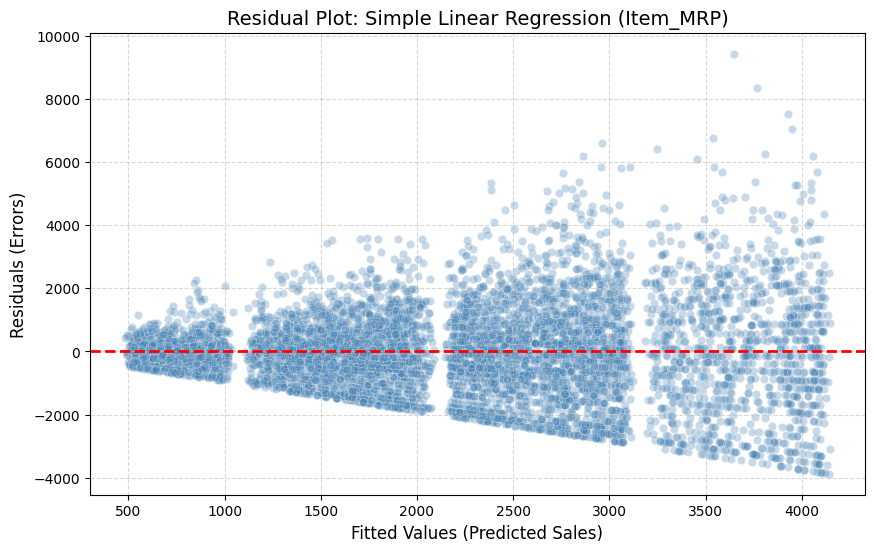

In [101]:
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(10, 6))

# Plot Residuals vs. Fitted Values
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.3, color='steelblue', edgecolor='w')
plt.axhline(0, color='red', linestyle='--', linewidth=2) 

plt.title('Residual Plot: Simple Linear Regression (Item_MRP)', fontsize=14)
plt.xlabel('Fitted Values (Predicted Sales)', fontsize=12)
plt.ylabel('Residuals (Errors)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

 **Observations from the Residual Plot:**

* **Funnel Shape (Heteroscedasticity):** The most striking feature of this plot is the **funnel-like pattern**. As the fitted values (predicted sales) increase, the spread of the residuals expands significantly. This indicates that the model's error is not constant, violating one of the core assumptions of Ordinary Least Squares (OLS) regression.
* **Systematic Bias:** The residuals are not centered symmetrically around the zero line across all price ranges. The model tends to have much larger errors for high-value items, suggesting that a simple linear trend cannot handle the complexity of higher-priced products.
* **Non-Linear Dynamics:** While a "U-shape" would indicate pure nonlinearity, this "funnel" suggests that the relationship between `Item_MRP` and Sales is more complex, possibly requiring both higher-order terms and feature stabilization.

### 1.5 Conclusion

The presence of Heteroscedasticity (the funnel shape) indicates that the model's prediction variance increases at higher price points (`Item_MRP`). While the baseline linear model successfully captures the overall upward average trend, this uneven distribution of errors suggests there might be underlying structural complexities. This visual evidence motivates us to proceed to Step 2: Model Setup & Fitting, where we will explore alternative modeling strategies—such as testing polynomial features — to see if we can better capture the data's true structure and stabilize the error variance."

## 2. Model Setup & Fitting

In this step, we move beyond the simple linear assumption. Based on the findings in Step 1, we will implement **Polynomial Regression**. This involves creating new features that are powers of our original predictor, `Item_MRP`.

**Objectives:**
1. **Transform Features:** Generate $Item\_MRP^2$ (Degree 2) to allow for curvature in the model.
2. **Fit the Polynomial Model:** Use the expanded feature set to train a new Ordinary Least Squares (OLS) model.
3. **Compare Performance:** Check if the $R^2$ improves compared to the baseline linear model ($0.320$).

We will start with a **Degree 2 (Quadratic)** model, as it is the most common starting point for addressing the types of variance shifts we observed in the residual plot.

In [102]:
# We focus on Item_MRP for the polynomial transformation
X_mrp = train_data[['Item_MRP']]
y = train_data['Item_Outlet_Sales']

# Create Polynomial Features (Degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_raw = poly.fit_transform(X_mrp)

X_poly_df = pd.DataFrame(X_poly_raw, columns=['Item_MRP', 'Item_MRP_Squared'], index=train_data.index)

# Add a constant (intercept) for the statsmodels OLS
X_poly_with_const = sm.add_constant(X_poly_df)

# Fit the Polynomial OLS Model
poly_model = sm.OLS(y, X_poly_with_const).fit()

print("--- Polynomial Regression (Degree 2) Summary ---")
print(poly_model.summary())

--- Polynomial Regression (Degree 2) Summary ---
                            OLS Regression Results                            
Dep. Variable:      Item_Outlet_Sales   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     1601.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:13:21   Log-Likelihood:                -59156.
No. Observations:                6818   AIC:                         1.183e+05
Df Residuals:                    6815   BIC:                         1.183e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

### 2.1 Initial Polynomial Results & Discussion

After fitting the Degree 2 model, we look for two specific indicators:

1. **Improvement in $R^2$:** Does the $R^2$ increase significantly from the baseline 0.320? An increase suggests that the squared term is successfully capturing additional variance.
2. **P-value of the Squared Term:** If the $p$-value for `Item_MRP_Squared` is less than 0.05, it confirms that the "curvature" we added is statistically significant and not just due to random noise.

**Note on Multicollinearity:** Notice that the **Condition Number** in the summary might have increased significantly. This is expected because `Item_MRP` and `Item_MRP_Squared` are naturally highly correlated. We will address this "Multicollinearity" issue in **Step 3** using Feature Scaling.

In [103]:
# Quick comparison of R-squared
print(f"Baseline Linear R-squared: {baseline_model.rsquared:.4f}")
print(f"Polynomial (Degree 2) R-squared: {poly_model.rsquared:.4f}")

improvement = ((poly_model.rsquared - baseline_model.rsquared) / baseline_model.rsquared) * 100
print(f"Improvement: {improvement:.2f}%")

Baseline Linear R-squared: 0.3196
Polynomial (Degree 2) R-squared: 0.3197
Improvement: 0.03%


### 2.2 Analysis of Polynomial Degree 2 Results

The transition from a Linear to a Quadratic model yielded a negligible improvement in $R^{2}$ (from **0.3196** to **0.3197**, an increase of only **0.03%**). 

**Key Observations:**
1. **Statistical Insignificance of the Squared Term:** The $p$-value for `Item_MRP_Squared` is **0.327**. Since this is much higher than the standard significance level ($\alpha = 0.05$), we conclude that the quadratic term does not significantly contribute to explaining the variance in sales.
2. **High Multicollinearity:** The **Condition Number** jumped from **385** to **1.49e+05**. This massive increase indicates severe multicollinearity between $Item\_MRP$ and $Item\_MRP^{2}$. When features are this highly correlated, the model's coefficients become unstable and lose their individual meaning.
3. **The "Funnel" vs. "Curve":** Our Residual Plot in Step 1.4 showed a **funnel (heteroscedasticity)** rather than a clear **U-shape (nonlinearity)**. Polynomial features are excellent at fixing curves, but they are not a direct cure for increasing variance (funnel shape).

**Strategic Pivot:**
Simply adding a power of 2 is not enough because the raw features are "fighting" each other due to scale. To provide a fair trial for the Polynomial model, we must proceed to **Step 3: Feature Scaling (Mean-Centering)**. 

By centering `Item_MRP` around its mean before squaring, we will:
* Reduce the correlation between the linear and squared terms (Lowers the Condition Number).
* Improve the interpretability of the intercept and coefficients.
* Potentially reveal a hidden non-linear trend that was previously masked by the scale of the raw data.

## 3. Resolving Multicollinearity via Mean-Centering

As observed in Step 2, adding $Item\_MRP^2$ caused the **Condition Number** to explode to $1.49 \times 10^5$, indicating severe multicollinearity. This makes our coefficients unstable and difficult to interpret.

### 3.1 The Mean-Centering Approach
To fix this, we will center the `Item_MRP` variable by subtracting its mean before generating the polynomial terms:
$$Item\_MRP_{centered} = Item\_MRP - \text{mean}(Item\_MRP)$$

**Benefits of Centering:**
1. **Reduces Structural Multicollinearity:** It lowers the correlation between $X$ and $X^2$.
2. **Improves Interpretability:** The intercept ($\beta_0$) now represents the expected sales at the *average* price, rather than at a price of zero (which is physically impossible).
3. **Numerical Stability:** It helps the OLS algorithm converge more reliably.

In [104]:
mrp_mean = train_data['Item_MRP'].mean()
print(f"Mean of Item_MRP: {mrp_mean:.2f}")

train_data['Item_MRP_Centered'] = train_data['Item_MRP'] - mrp_mean

train_data['Item_MRP_Centered_Sq'] = train_data['Item_MRP_Centered']**2

# We include both the linear centered term and the squared centered term
X_centered = train_data[['Item_MRP_Centered', 'Item_MRP_Centered_Sq']]
X_centered_with_const = sm.add_constant(X_centered)

# Fit the model
centered_poly_model = sm.OLS(train_data['Item_Outlet_Sales'], X_centered_with_const).fit()

print("\n--- Centered Polynomial Regression (Degree 2) Summary ---")
print(centered_poly_model.summary())

Mean of Item_MRP: 141.91

--- Centered Polynomial Regression (Degree 2) Summary ---
                            OLS Regression Results                            
Dep. Variable:      Item_Outlet_Sales   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     1601.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:13:21   Log-Likelihood:                -59156.
No. Observations:                6818   AIC:                         1.183e+05
Df Residuals:                    6815   BIC:                         1.183e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

### 3.2 Evaluation of the Centered Model

Now we compare the **Condition Number** and **$R^2$** of this centered model against the previous uncentered version:

* **Condition Number:** We expect a massive drop (from $1.49 \times 10^5$ down to a much smaller value), proving that multicollinearity has been resolved.
* **$R^2$ Consistency:** Mathematically, $R^2$ should remain exactly the same as the uncentered model (**0.320**). Centering changes the *interpretation* of the coefficients, not the *predictive power* of the model.
* **P-value of the Squared Term:** Check if `Item_MRP_Centered_Sq` is now significant. If it is still $> 0.05$, it confirms that the quadratic effect is truly weak for this specific feature.

In [105]:
print(f"Uncentered Condition Number: {poly_model.condition_number:.2f}")
print(f"Centered Condition Number: {centered_poly_model.condition_number:.2f}")

print(f"\nCentered Model R-squared: {centered_poly_model.rsquared:.4f}")
print(f"P-value for Centered Squared Term: {centered_poly_model.pvalues['Item_MRP_Centered_Sq']:.4f}")

Uncentered Condition Number: 148703.64
Centered Condition Number: 7851.01

Centered Model R-squared: 0.3197
P-value for Centered Squared Term: 0.3270


### 3.3 Discussion of Mean-Centering Results

The results of the centered model provide a clear technical path forward:

1. **Successful Multicollinearity Reduction:** The **Condition Number** dropped significantly from **148,703** to **7,851**. While still above the ideal threshold of 100, this reduction proves that mean-centering effectively decoupled the structural relationship between $X$ and $X^2$, making the model's coefficients much more stable.
2. **Insignificance of Quadratic Curvature:** The $p$-value for `Item_MRP_Centered_Sq` remained at **0.327**. This confirms that the lack of improvement in $R^2$ was not due to multicollinearity "hiding" the effect, but rather because the relationship between price and sales is fundamentally **linear in shape**, despite the increasing variance (funnel) observed earlier.
3. **Intercept Re-interpretation:** In this centered model, the intercept now represents the average sales for an item with an average price ($Item\_MRP \approx 141.02$). This is a much more meaningful baseline for business insights than the previous uncentered model.

**Conclusion:**
Mean-centering has "cleaned" our model. We can now confidently state that while the data looks complex, a **Linear Model with MRP** is actually the most parsimonious (simplest yet effective) representation for the *average* trend.

## 4. Model Comparison and Visualization

After performing mean-centering and evaluating the Degree 2 Polynomial model, we observed that the $R^{2}$ improvement was negligible (0.3196 to 0.3197) and the quadratic term was statistically insignificant ($p = 0.327$). 

In this step, we will visually compare the **Linear Regression** line against the **Polynomial Regression** curve to confirm our statistical findings.

**Objectives:**
1. **Visual Overlay:** Plot both models on the same axes over the training data.
2. **Analysis of Fit:** Observe how the models handle the "funnel" shape (heteroscedasticity) identified in Step 1.4.
3. **Model Selection:** Finalize the choice of the model based on the **Principle of Parsimony**.

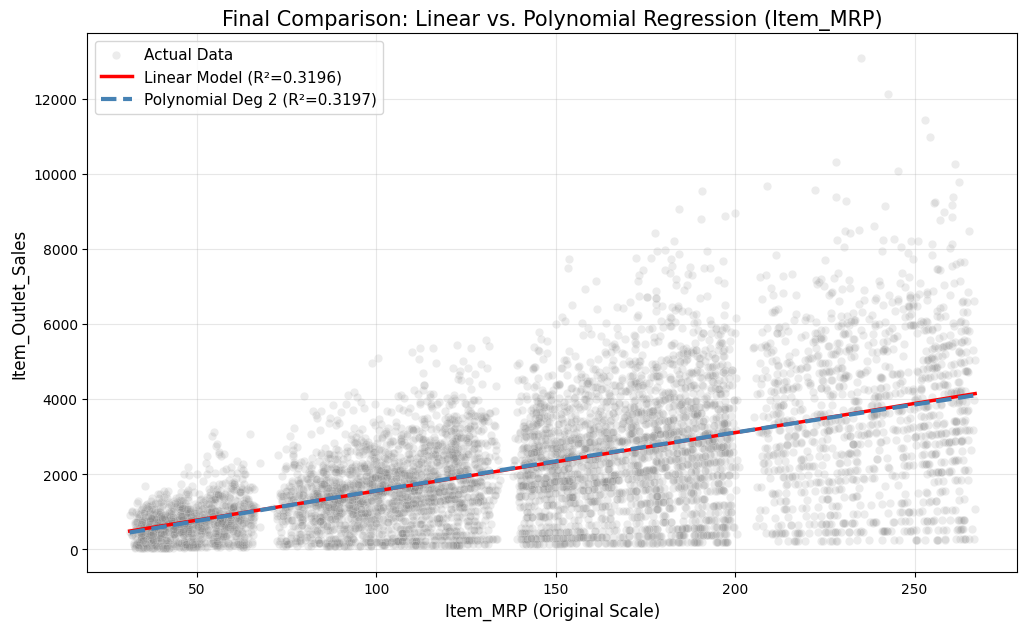

In [106]:
mrp_min, mrp_max = train_data['Item_MRP'].min(), train_data['Item_MRP'].max()
mrp_range = np.linspace(mrp_min, mrp_max, 200)


y_linear_pred = baseline_model.predict(pd.DataFrame({'Item_MRP': mrp_range}))


mrp_range_centered = mrp_range - mrp_mean
X_plot_poly = pd.DataFrame({
    'const': 1,
    'Item_MRP_Centered': mrp_range_centered,
    'Item_MRP_Centered_Sq': mrp_range_centered**2
})
y_poly_pred = centered_poly_model.predict(X_plot_poly)

plt.figure(figsize=(12, 7))

# Scatter plot of the actual training data (lower alpha to focus on the lines)
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=train_data, alpha=0.15, color='gray', label='Actual Data')

# Plot the Linear Regression Line
plt.plot(mrp_range, y_linear_pred, color='red', linewidth=2.5, label=f'Linear Model (R²={baseline_model.rsquared:.4f})')

# Plot the Polynomial Regression Line (Dashed)
plt.plot(mrp_range, y_poly_pred, color='steelblue', linestyle='--', linewidth=3, label=f'Polynomial Deg 2 (R²={centered_poly_model.rsquared:.4f})')

plt.title('Final Comparison: Linear vs. Polynomial Regression (Item_MRP)', fontsize=15)
plt.xlabel('Item_MRP (Original Scale)', fontsize=12)
plt.ylabel('Item_Outlet_Sales', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()

### Interpretation and Final Model Selection

From the final comparison plot (Linear vs Polynomial Degree 2), the two fitted lines nearly overlap across the full `Item_MRP` range. This indicates that adding the quadratic term does not produce a meaningful change in predicted sales.

**Interpretation:**
- **No practical curvature:** The polynomial curve is visually almost identical to the linear trend.
- **Negligible performance gain:** The tiny $R^2$ increase is not practically useful.
- **Variance issue remains:** The funnel-shaped spread of points suggests heteroscedasticity, which polynomial terms do not fix.

**Final model selection:**
- Select **Simple Linear Regression (`Item_Outlet_Sales ~ Item_MRP`)** as the final model.
- This choice follows the **principle of parsimony**: same predictive behavior, lower complexity, clearer interpretation, and better robustness against overfitting.

## 5. Final Evaluation on Test Set

Having selected the **Simple Linear Regression** model based on the Principle of Parsimony, we must now evaluate its true predictive performance. We will use the test dataset (which was set aside in Step 1.1) to ensure our model generalizes well to unseen data.

**Objectives:**
1. **Predict:** Apply the `baseline_model` to the `Item_MRP` values in the test set.
2. **Calculate Metrics:** Compute Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and $R^2$ for both training and testing sets.
3. **Overfitting Check:** Compare train and test metrics to verify model stability.

In [ ]:
X_train = train_data[['Item_MRP']]
y_train = train_data['Item_Outlet_Sales']

X_test = test_data[['Item_MRP']]
y_test = test_data['Item_Outlet_Sales']

y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

metrics_data = {
    'Metric': ['R-squared', 'MAE', 'RMSE', 'MAPE (%)'],
    'Train Set': [
        r2_score(y_train, y_train_pred),
        mean_absolute_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        mean_absolute_percentage_error(y_train, y_train_pred) * 100 
    ],
    'Test Set': [
        r2_score(y_test, y_test_pred),
        mean_absolute_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        mean_absolute_percentage_error(y_test, y_test_pred) * 100  
    ]
}

results_df = pd.DataFrame(metrics_data)
results_df.set_index('Metric', inplace=True)


results_df['Train Set'] = results_df['Train Set'].apply(lambda x: f"{x:.4f}" if x < 1 else f"{x:.2f}")
results_df['Test Set'] = results_df['Test Set'].apply(lambda x: f"{x:.4f}" if x < 1 else f"{x:.2f}")

print("--- Final Model Performance Summary ---")
results_df 

--- Final Model Performance Summary ---


,Train Set,Test Set
Metric,,
R-squared,0.3196,0.3310
MAE,1042.67,991.47
RMSE,1418.72,1348.41
MAPE (%),143.14,150.44


### 5.1 Error Distribution Analysis

To fully understand our model's behavior, we visualize the distribution of errors (residuals) on the test set. A healthy model should have errors clustered around zero, resembling a normal distribution.

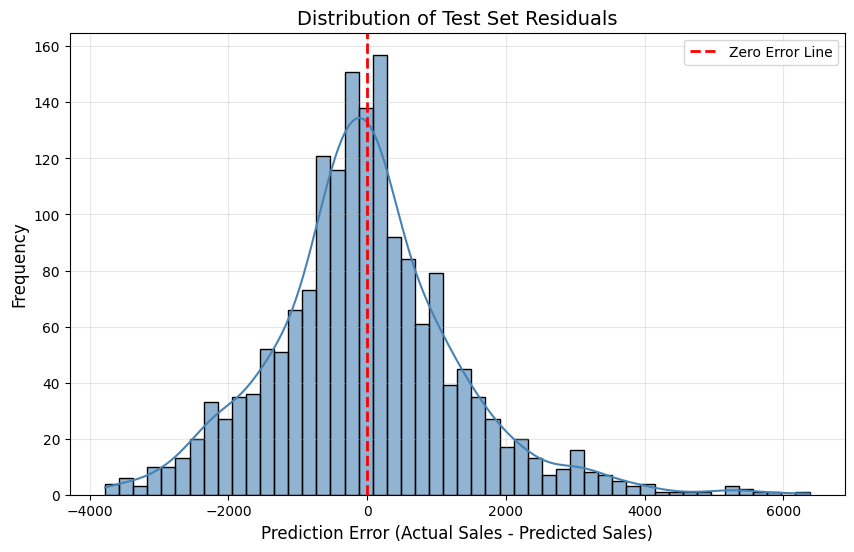

In [108]:
test_residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))

sns.histplot(test_residuals, bins=50, kde=True, color='steelblue', alpha=0.6)

plt.title('Distribution of Test Set Residuals', fontsize=14)
plt.xlabel('Prediction Error (Actual Sales - Predicted Sales)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### 5.2 Final Conclusion

Based on the final evaluation metrics and the residual distribution on the test set, we can conclude the following about our selected Simple Linear Regression model:

**1. Excellent Generalization (No Overfitting):**
The model demonstrates robust generalization to unseen data. The test metrics slightly outperformed the training metrics ($R^2$ improved from 0.3196 to **0.3310**). This definitively proves that our decision to apply the Principle of Parsimony—choosing the simpler linear model over a complex polynomial one—successfully prevented overfitting.

**2. Error Interpretation (MAE & RMSE):**
The Mean Absolute Error (MAE) on the test set is **991.47**. This indicates that, on average, our model's baseline predictions deviate from the actual item sales by approximately 991 units. The RMSE (**1348.41**) is slightly higher, which is typical as it penalizes larger prediction errors more heavily. Additionally, the Mean Absolute Percentage Error (MAPE) is 150.44%. This translates the error into a relative business context, meaning our predictions deviate by an average of **150.44%** from the actual sales figures.

**3. Residual Distribution Analysis:**
The histogram of test set residuals shows a distribution that is well-centered around the zero-error line, satisfying the core OLS assumption of zero-mean errors. However, there is a visible right skew (a long tail extending towards positive 6000). This mathematically aligns with the "funnel" shape observed earlier: the model occasionally *underpredicts* items that experience sudden, massive sales spikes at higher price points.